In [41]:
import sys
import os
import importlib

#--------------------------------------------------------------
# clearing cache so that the core.py is called from the right place, had issue earlier
modules_to_clear = [
    m for m in sys.modules.keys() 
    if any(p in m for p in ["models", "src", "data", "metrics"])
]
for module in modules_to_clear:
    del sys.modules[module]
PROJECT_ROOT = "/Users/darya/Desktop/Diploma/COMPAS - criminals/whole_process"
sys.path = [p for p in sys.path if "COMPAS - criminals" not in p]
sys.path.insert(0, PROJECT_ROOT)
cox_upd_path = os.path.join(PROJECT_ROOT, "models", "cox_model_upd.py")
spec = importlib.util.spec_from_file_location("cox_model_upd", cox_upd_path)
cox_model_upd = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cox_model_upd)
CoxModelUpd = cox_model_upd.CoxModelUpd
#issue with the ibs_metric part because of numba, i beleive this helped fix it
os.environ["NUMBA_DISABLE_JIT"] = "1"
#--------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#from data.data_processor import DataProcessor
from data.data_processor_fix import DataProcessor as DP
from data.splitter import SurvivalSplitter
from models.cox_model import CoxModel
from models.cox_model_upd import CoxModelUpd
from metrics.ibs import IBSMetric
from metrics.ibs_remain import IBSRemainMetric
from metrics.auprc import AUPRCMetric
from metrics.recurrent_count_error import RecurrentCountError
from pipeline.evaluator import SurvivalEvaluator
from survivors.constants import get_y

In [42]:
df = pd.read_csv('data/individual_custody_timeline_rfm.csv')
print(df.columns)

Index(['name', 'age', 'sex', 'race', 'c_charge_degree', 'c_charge_desc',
       'in_custody', 'out_custody', 'custody_num', 'time_to_last_custody',
       'time_since_last_arrest', 'time_to_future_arrest', 'event',
       'event_of_future_arrest', 'curr_dur_custody', 'sum_dur_custody',
       'average_dur_custody', 'all_future_arrest_times', 'all_future_events'],
      dtype='object')


In [43]:
processor = DP("data/individual_custody_timeline_rfm.csv")
cox_df = processor.load_and_prepare()
cox_df.head(30)

,name,episode_col,entry,dur,event,age,time_since_last_arrest,average_dur_custody,curr_dur_custody
0,aajah herrington,1,0,385,0,23,384.0,1.00,23.0
1,aaron aprile,1,0,55,0,27,0.0,55.00,510.0
2,aaron davis,1,0,432,0,41,314.0,118.00,8.0
3,aaron eddins,1,0,104,0,37,104.0,0.00,32.0
4,aaron epstein,1,0,297,1,22,296.0,1.00,1.0
5,aaron epstein,2,297,357,1,22,59.0,1.00,50.0
6,aaron epstein,3,357,430,0,22,23.0,17.33,10.0
7,aaron evans,1,0,95,1,26,94.0,1.00,0.0
8,aaron evans,2,95,318,1,26,223.0,0.50,1.0
9,aaron evans,3,318,425,0,26,106.0,0.67,14.0


In [44]:
'''# importlib.reload(data.data_processor)

processor = DataProcessor("data/individual_custody_timeline_rfm.csv")
cox_df = processor.load_and_prepare()
cox_df = pd.get_dummies(
    cox_df,
    columns=["sex", "race"],
    drop_first=True
)
cox_df.head(20)'''

'# importlib.reload(data.data_processor)\n\nprocessor = DataProcessor("data/individual_custody_timeline_rfm.csv")\ncox_df = processor.load_and_prepare()\ncox_df = pd.get_dummies(\n    cox_df,\n    columns=["sex", "race"],\n    drop_first=True\n)\ncox_df.head(20)'

Data split into train and test data

In [45]:
splitter = SurvivalSplitter(test_size=0.2)
train_df, test_df = splitter.split_by_individual(cox_df)
train_df = train_df.drop(columns=["curr_dur_custody"])
test_df = test_df.drop(columns=["curr_dur_custody"])

print("Train individuals:", train_df["name"].nunique())
print("Test individuals:", test_df["name"].nunique())

Train individuals: 3382
Test individuals: 845


In [46]:
train_df["time"] = train_df["entry"] + train_df["dur"]
test_df["time"] = test_df["entry"] + test_df["dur"]

train_cens = train_df["event"].astype(bool)
test_cens = test_df["event"].astype(bool)

survival_train = get_y(
    cens=train_cens,
    time=train_df["time"],
    competing=False
)

survival_test = get_y(
    cens=test_cens,
    time=test_df["time"],
    competing=False
)


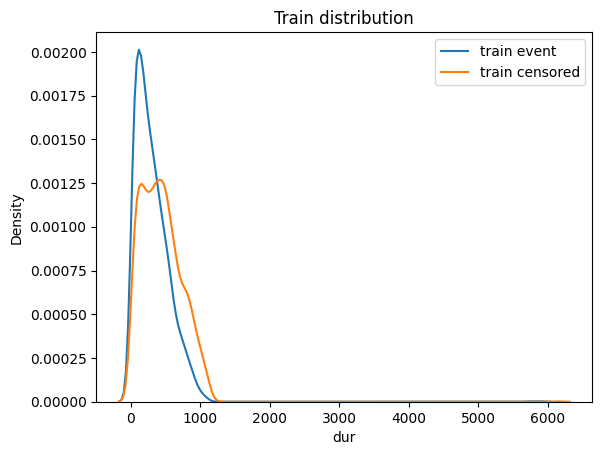

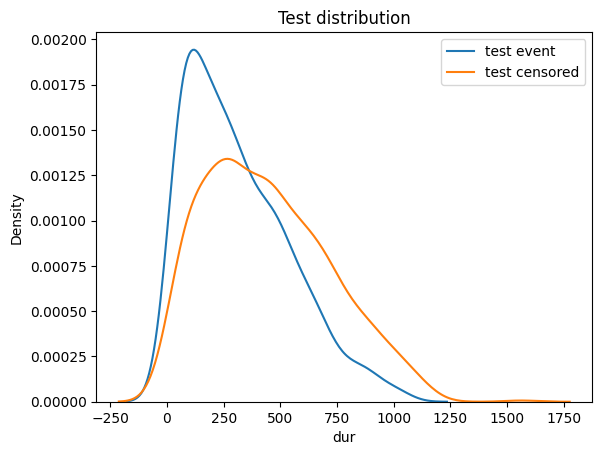

Train events: event
0    3382
1    2767
Name: count, dtype: int64
Test events: event
0    845
1    778
Name: count, dtype: int64


In [47]:
plt.figure()
sns.kdeplot(train_df[train_df["event"]==1]["dur"], label="train event")
sns.kdeplot(train_df[train_df["event"]==0]["dur"], label="train censored")
plt.legend()
plt.title("Train distribution")
plt.show()

plt.figure()
sns.kdeplot(test_df[test_df["event"]==1]["dur"], label="test event")
sns.kdeplot(test_df[test_df["event"]==0]["dur"], label="test censored")
plt.legend()
plt.title("Test distribution")
plt.show()

print("Train events:", train_df["event"].value_counts())
print("Test events:", test_df["event"].value_counts())


Using the original CoxModel file that I had (cox_model.py)

In [48]:
# importlib.reload(models.cox_model)

print(train_df.columns)

features = [c for c in train_df.columns 
            if c not in ["name", "entry", "time", "event", "dur", "episode_col"]]
print(features)

cols_for_model = ["name", "entry", "time", "event"] + features
train_model_df = train_df[cols_for_model].copy().fillna(-1)
test_df = test_df.fillna(-1)

model = CoxModel(features=features)
model.fit(train_model_df)

Index(['name', 'episode_col', 'entry', 'dur', 'event', 'age',
       'time_since_last_arrest', 'average_dur_custody', 'time'],
      dtype='object')
['age', 'time_since_last_arrest', 'average_dur_custody']


model,lifelines.CoxPHFitter
duration col,'time'
event col,'event'
entry col,'entry'
cluster col,'name'
robust variance,True
baseline estimation,breslow
number of observations,6149
number of events observed,2767
partial log-likelihood,-20338.16
time fit was run,2026-03-06 07:05:42 UTC


<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>


In [49]:
train_model_df.query("name=='aaron epstein'")

,name,entry,time,event,age,time_since_last_arrest,average_dur_custody
4,aaron epstein,0,297,1,22,296.0,1.00
5,aaron epstein,297,654,1,22,59.0,1.00
6,aaron epstein,357,787,0,22,23.0,17.33


In [50]:
train_model_df["time_since_last_arrest"].value_counts()

time_since_last_arrest
 0.0       338
 21.0       34
 25.0       33
 20.0       32
 19.0       32
          ... 
-42.0        1
 1066.0      1
 665.0       1
 868.0       1
 584.0       1
Name: count, Length: 880, dtype: int64

In [51]:
train_model_df

,name,entry,time,event,age,time_since_last_arrest,average_dur_custody
0,aajah herrington,0,385,0,23,384.0,1.0
1,aaron aprile,0,55,0,27,0.0,55.0
2,aaron davis,0,432,0,41,314.0,118.0
3,aaron eddins,0,104,0,37,104.0,0.0
4,aaron epstein,0,297,1,22,296.0,1.0
...,...,...,...,...,...,...,...
6144,zavier harris,0,302,0,20,0.0,302.0
6145,zaysha clark,0,430,0,24,429.0,1.0
6146,zechariah faulk,0,69,0,28,69.0,0.0
6147,zeke zikria,0,152,0,46,150.0,2.0


In [52]:
train_df["dur"].describe()

count    6149.000000
mean      381.495853
std       289.923100
min         1.000000
25%       159.000000
50%       336.000000
75%       547.000000
max      6141.000000
Name: dur, dtype: float64

In [53]:
survival_test = get_y(
    cens=test_cens,
    time=test_df["time"],
    competing=False
)

In [54]:
test_df

,name,episode_col,entry,dur,event,age,time_since_last_arrest,average_dur_custody,time
0,aaron hammond,1,0,699,0,25,688.0,11.0,699
1,aaron villacampa,1,0,107,0,26,106.0,1.0,107
2,abraham ballestas,1,0,35,0,52,34.0,1.0,35
3,acie canteen,1,0,215,0,27,214.0,1.0,215
4,adam gillstrap,1,0,630,0,35,628.0,2.0,630
...,...,...,...,...,...,...,...,...,...
1618,zachary payton,1,0,34,0,28,33.0,1.0,34
1619,zachary whalen,1,0,634,0,24,632.0,2.0,634
1620,zaheer khan,1,0,184,0,26,183.0,1.0,184
1621,zhivago walker,1,0,126,0,30,125.0,1.0,126


In [55]:
from lifelines.utils import concordance_index
#times = np.linspace(0, train_df["dur"].max(), 200)
horizon = np.quantile(train_model_df["time"], 0.95)
times = np.linspace(0, horizon, 200)

test_features = test_df[features].copy()
predictions = model.predict_survival(test_features, times)
#predictions = model.predict_survival(test_df, times)
estimate = predictions.values
estimate = np.asarray(estimate, dtype=np.float64)
times = np.asarray(times, dtype=np.float64)

survival_train = survival_train.astype([("event", "?"), ("time", "f8")])
survival_test = survival_test.astype([("event", "?"), ("time", "f8")])

print(survival_test.dtype.names)
ibs_metric = IBSMetric()
mean_ibs, ibs_by_time = ibs_metric.compute(
    survival_train,
    survival_test,
    estimate,
    times
)

print(mean_ibs)

survival_train_cens = survival_train.astype([("cens", "?"), ("time", "f8")])
survival_test_cens = survival_test.astype([("cens", "?"), ("time", "f8")])

auprc_metric = AUPRCMetric()
auprc = auprc_metric.compute(
    survival_train_cens,
    survival_test_cens,
    estimate,
    times
)
print("AUPRC:", np.mean(auprc))

ci_metric = concordance_index(
    test_df["dur"],
    np.trapz(predictions.values, times, axis=1),
    test_cens
)
print("Concordance Index:", ci_metric)

('event', 'time')
0.2343354024684467
AUPRC: 0.553431608336475
Concordance Index: 0.7403699875580877


In [56]:
predictions

,0.000000,7.068342,14.136683,21.205025,28.273367,35.341709,42.410050,49.478392,56.546734,63.615075,...,1342.984925,1350.053266,1357.121608,1364.189950,1371.258291,1378.326633,1385.394975,1392.463317,1399.531658,1406.600000
0,1.0,0.999620,0.998687,0.997666,0.996840,0.995642,0.994229,0.992504,0.991305,0.989812,...,0.806563,0.806203,0.806203,0.805843,0.805105,0.804480,0.804353,0.803579,0.802795,0.802795
1,1.0,0.996900,0.989313,0.981073,0.974445,0.964906,0.953766,0.940310,0.931061,0.919655,...,0.172337,0.171709,0.171709,0.171083,0.169806,0.168730,0.168513,0.167192,0.165861,0.165861
2,1.0,0.996452,0.987776,0.978363,0.970801,0.959930,0.947254,0.931972,0.921485,0.908574,...,0.133617,0.133060,0.133060,0.132504,0.131373,0.130421,0.130228,0.129060,0.127885,0.127885
3,1.0,0.997885,0.992699,0.987053,0.982500,0.975931,0.968232,0.958895,0.952453,0.944479,...,0.301451,0.300702,0.300702,0.299954,0.298426,0.297135,0.296873,0.295284,0.293679,0.293679
4,1.0,0.999524,0.998354,0.997075,0.996040,0.994539,0.992770,0.990610,0.989110,0.987243,...,0.763741,0.763314,0.763314,0.762886,0.762011,0.761269,0.761118,0.760201,0.759270,0.759270
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618,1.0,0.996034,0.986344,0.975842,0.967414,0.955311,0.941219,0.924260,0.912641,0.898357,...,0.105380,0.104889,0.104889,0.104399,0.103404,0.102566,0.102397,0.101371,0.100339,0.100339
1619,1.0,0.999507,0.998295,0.996970,0.995897,0.994342,0.992510,0.990273,0.988719,0.986785,...,0.756340,0.755902,0.755902,0.755464,0.754566,0.753804,0.753650,0.752708,0.751753,0.751753
1620,1.0,0.997632,0.991829,0.985514,0.980426,0.973089,0.964498,0.954089,0.946915,0.938043,...,0.261141,0.260414,0.260414,0.259689,0.258208,0.256957,0.256705,0.255166,0.253614,0.253614
1621,1.0,0.997151,0.990175,0.982594,0.976492,0.967705,0.957433,0.945014,0.936468,0.925920,...,0.198738,0.198073,0.198073,0.197409,0.196055,0.194913,0.194683,0.193280,0.191865,0.191865


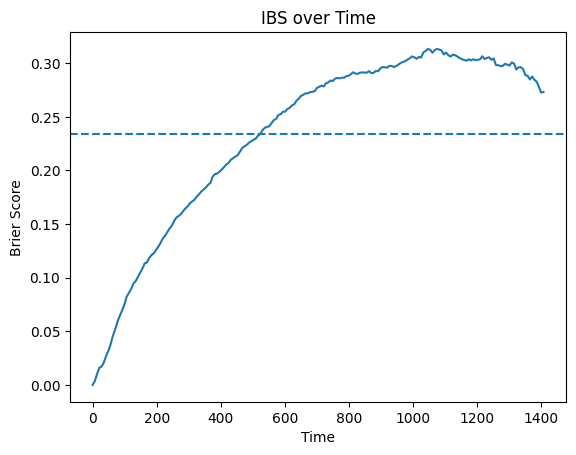

In [57]:
plt.plot(times, ibs_by_time)
plt.axhline(y=mean_ibs, linestyle="--")
plt.title("IBS over Time")
plt.xlabel("Time")
plt.ylabel("Brier Score")
plt.show()

In [58]:
from survivors import metrics
test_df_results = test_df[["name", "episode_col", "dur", "event"]].copy()

test_df_results["dur"] = test_df["dur"] - test_df["entry"]

test_df_results["ibs"] = metrics.ibs(
            survival_train=survival_train,
            survival_test=survival_test,
            estimate=estimate,
            times=times,
            axis=0
        )
test_df_results["auprc"] = metrics.auprc(
            survival_train=survival_train_cens,
            survival_test=survival_test_cens,
            estimate=estimate,
            times=times,
            axis=0
        )

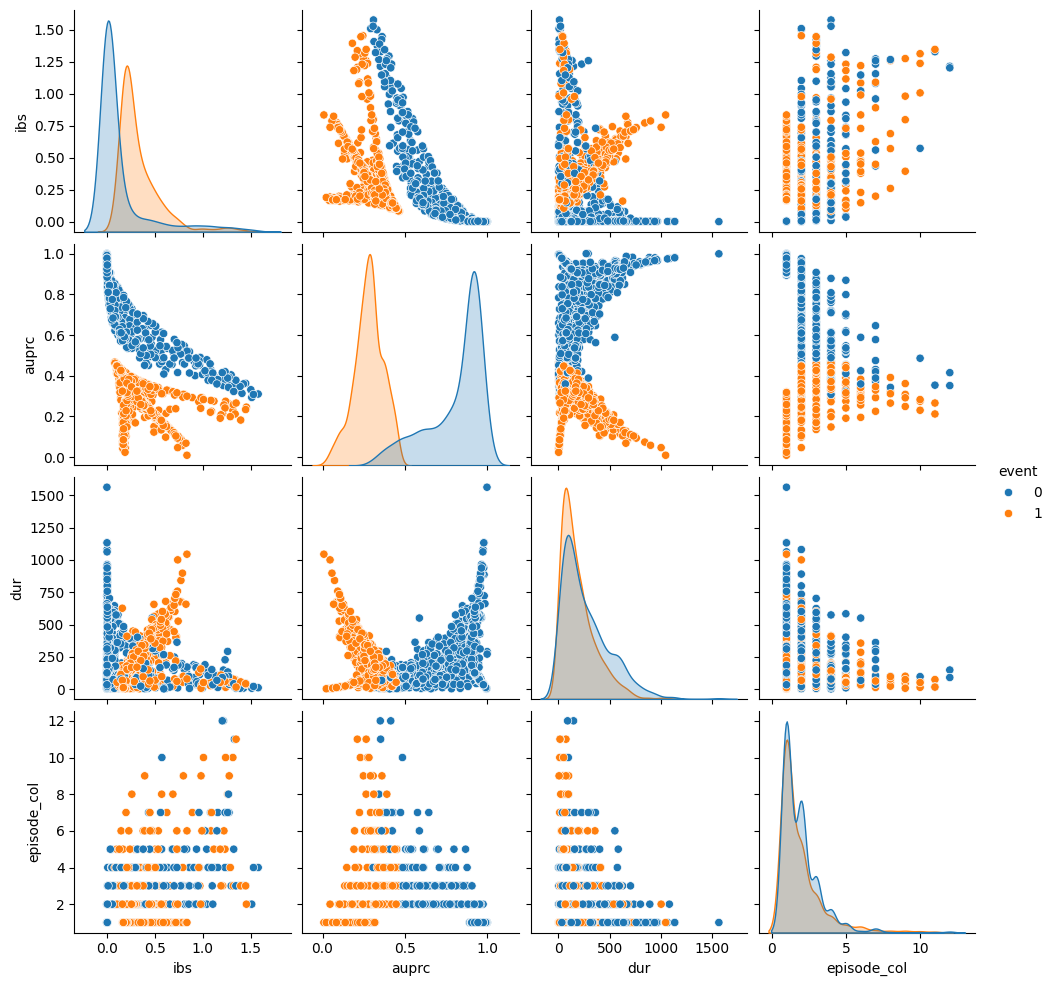

In [59]:
# sns.scatterplot(x="episode_col", y="auprc", data=test_df_results)
sns.pairplot(test_df_results, vars=["ibs", "auprc", "dur", "episode_col"], hue="event")

In [60]:
test_df_results[test_df_results["episode_col"] >= 8].round(3)
# test_df["dur"].describe()

,name,episode_col,dur,event,ibs,auprc
216,brandon ross,8,47,1,1.259,0.265
217,brandon ross,9,47,1,1.275,0.248
218,brandon ross,10,67,1,1.313,0.230
219,brandon ross,11,74,1,1.336,0.211
220,brandon ross,12,148,0,1.214,0.351
592,eric redmond,8,23,1,0.688,0.320
593,eric redmond,9,100,1,0.797,0.308
594,eric redmond,10,14,1,1.237,0.274
595,eric redmond,11,18,0,1.328,0.353
770,jason jaigobin,8,99,0,1.267,0.342


<Axes: xlabel='episode_col', ylabel='ibs'>

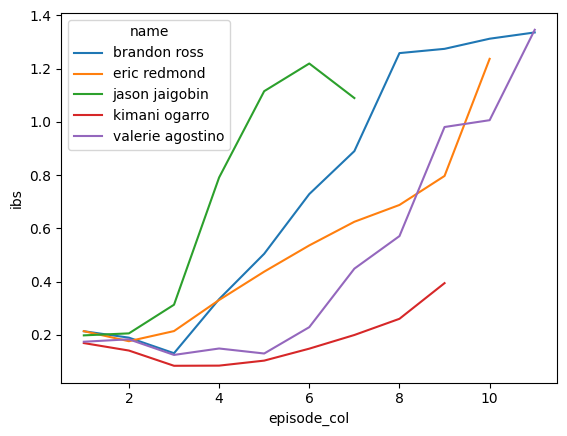

In [61]:
freq_name = test_df_results.query("episode_col >= 8")["name"].unique()
sns.lineplot(x="episode_col", y="ibs", hue="name",
                data=test_df_results.query(f"name.isin({list(freq_name)}) and (event == 1)"))

<Axes: xlabel='episode_col'>

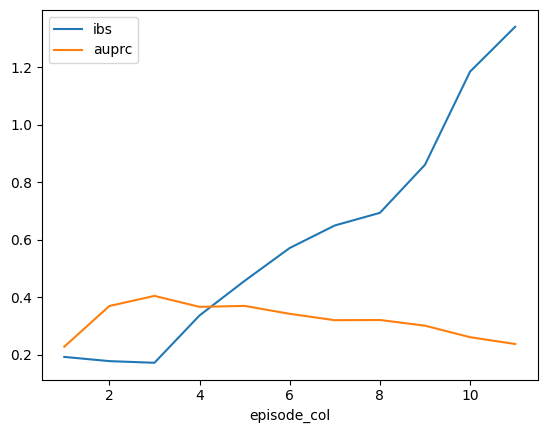

In [62]:
test_df_results.query(f"name.isin({list(freq_name)}) and (event == 1)").groupby("episode_col")[["ibs", "auprc"]].mean().plot()

In [63]:
# tr_pred = 1 - model.predict_survival(train_df, times).values.T
tr_pred = model.predict_cumulative_hazard(train_df, times)
tr_max = np.quantile(tr_pred.max(), 0.95)

# pred = 1 - model.predict_survival(test_df, times).values.T
# test_df.drop_duplicates(["name"], keep='first')
pred = model.predict_cumulative_hazard(test_df, times)
# pred[:] = train_df.groupby("name")["event"].sum().mean()  // baseline случай фиксированного числа событий
print("pred shape:", pred.shape)
print("len(test_df):", len(test_df))
metric = RecurrentCountError()

recurrent_error = metric.compute(
    survival_train=None,
    survival_test=test_df,
    estimate=pred / tr_max,
    times=times
)

mean_events = test_df.groupby("name")["event"].sum().mean()
print("Mean event =", mean_events)
print("Integrated cumulative event error:", recurrent_error)

pred shape: (200, 1623)
len(test_df): 1623
Mean event = 0.9207100591715977
Integrated cumulative event error: 0.2549225444051514


In [64]:
pred

,0,1,2,3,4,5,6,7,8,9,...,1613,1614,1615,1616,1617,1618,1619,1620,1621,1622
0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7.068342,0.000380,0.003105,0.003555,0.002118,0.000476,0.001038,0.004331,0.001726,0.002950,0.003121,...,0.000573,0.004311,0.000549,0.000595,0.000213,0.003974,0.000493,0.002371,0.002853,0.000325
14.136683,0.001314,0.010745,0.012300,0.007328,0.001647,0.003590,0.014986,0.005973,0.010208,0.010799,...,0.001982,0.014919,0.001898,0.002058,0.000737,0.013750,0.001707,0.008205,0.009874,0.001123
21.205025,0.002336,0.019109,0.021874,0.013032,0.002929,0.006385,0.026652,0.010623,0.018154,0.019206,...,0.003524,0.026532,0.003376,0.003660,0.001311,0.024454,0.003035,0.014592,0.017560,0.001997
28.273367,0.003165,0.025887,0.029633,0.017655,0.003968,0.008650,0.036106,0.014391,0.024594,0.026018,...,0.004774,0.035943,0.004574,0.004958,0.001776,0.033129,0.004111,0.019768,0.023788,0.002706
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1378.326633,0.217559,1.779453,2.036990,1.213570,0.272769,0.594600,2.481936,0.989231,1.690562,1.788502,...,0.328166,2.470739,0.314411,0.340783,0.122048,2.277251,0.282623,1.358845,1.635200,0.185976
1385.394975,0.217717,1.780743,2.038465,1.214449,0.272967,0.595030,2.483735,0.989948,1.691787,1.789797,...,0.328404,2.472529,0.314639,0.341030,0.122137,2.278900,0.282828,1.359830,1.636385,0.186111
1392.463317,0.218679,1.788613,2.047475,1.219817,0.274173,0.597660,2.494712,0.994323,1.699265,1.797708,...,0.329855,2.483458,0.316029,0.342538,0.122677,2.288973,0.284078,1.365840,1.643617,0.186933
1399.531658,0.219656,1.796606,2.056625,1.225268,0.275398,0.600331,2.505860,0.998766,1.706858,1.805741,...,0.331329,2.494555,0.317442,0.344068,0.123225,2.299201,0.285347,1.371943,1.650962,0.187769


In [65]:
test_df.drop_duplicates(["name"], keep='first')

,name,episode_col,entry,dur,event,age,time_since_last_arrest,average_dur_custody,time
0,aaron hammond,1,0,699,0,25,688.0,11.0,699
1,aaron villacampa,1,0,107,0,26,106.0,1.0,107
2,abraham ballestas,1,0,35,0,52,34.0,1.0,35
3,acie canteen,1,0,215,0,27,214.0,1.0,215
4,adam gillstrap,1,0,630,0,35,628.0,2.0,630
...,...,...,...,...,...,...,...,...,...
1618,zachary payton,1,0,34,0,28,33.0,1.0,34
1619,zachary whalen,1,0,634,0,24,632.0,2.0,634
1620,zaheer khan,1,0,184,0,26,183.0,1.0,184
1621,zhivago walker,1,0,126,0,30,125.0,1.0,126


Using the updated CoxModelUpd file (cox_model_upd.py). RECURRENT WITH EPISODE_COL case

In [66]:
# RECURRENT WITH EPISODE_COL
features1 = [c for c in train_df.columns 
            if c not in ["name", "entry", "time", "event", "dur"]]

cols_for_model1 = ["name", "episode_col", "entry", "time", "event"] + \
                 [c for c in features1 if c != "episode_col"]

train_model_df1 = train_df[cols_for_model1].copy().fillna(-1)

model1 = CoxModelUpd(
    features=[c for c in features1 if c != "episode_col"],
    mode="recurrent",
    use_episode=True
)

model1.fit(train_model_df1)


model,lifelines.CoxPHFitter
duration col,'time'
event col,'event'
entry col,'entry'
cluster col,'name'
robust variance,True
strata,episode_col
baseline estimation,breslow
number of observations,6149
number of events observed,2767
partial log-likelihood,-16701.85


<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>


In [67]:
from lifelines.utils import concordance_index
#times = np.linspace(0, train_df["dur"].max(), 200)
train_dur1 = train_model_df1["time"]
horizon1 = np.quantile(train_dur1, 0.95)
times1 = np.linspace(0, horizon1, 200)

test_model_df1 = test_df[cols_for_model1].copy().fillna(-1)

print("Train episodes:", sorted(train_model_df1["episode_col"].unique()))
print("Test episodes:", sorted(test_model_df1["episode_col"].unique()))

# had an issue with strata, so removing unseen strata
valid_episodes = train_model_df1["episode_col"].unique()
test_model_df1 = test_model_df1[
    test_model_df1["episode_col"].isin(valid_episodes)
]


predictions1 = model1.predict_survival(test_model_df1, times1)
#predictions = model.predict_survival(test_df, times)
estimate1 = predictions1.values.astype(np.float64)
times1 = np.asarray(times1, dtype=np.float64)

test_dur1 = test_model_df1["time"]

survival_test1 = np.array(
    list(zip(
        test_model_df1["event"].astype(bool),
        test_dur1.astype(float)
    )),
    dtype=[("event", "?"), ("time", "f8")]
)

survival_train1 = np.array(
    list(zip(
        train_model_df1["event"].astype(bool),
        train_dur1.astype(float)
    )),
    dtype=[("event", "?"), ("time", "f8")]
)
print(survival_test1.dtype.names)


ibs_metric1 = IBSMetric()
mean_ibs1, ibs_by_time1 = ibs_metric.compute(
    survival_train1,
    survival_test1,
    estimate1,
    times1
)

print("IBS:", mean_ibs1)

survival_test_cens1 = np.array(
    list(zip(
        (~test_model_df1["event"].astype(bool)),
        test_dur1.astype(float)
    )),
    dtype=[("cens", "?"), ("time", "f8")]
)

survival_train_cens1 = np.array(
    list(zip(
        (~train_model_df1["event"].astype(bool)),
        train_dur1.astype(float)
    )),
    dtype=[("cens", "?"), ("time", "f8")]
)

auprc_metric1 = AUPRCMetric()
auprc1 = auprc_metric1.compute(
    survival_train_cens1,
    survival_test_cens1,
    estimate1,
    times1
)
print("AUPRC:", np.mean(auprc1))

ci_metric1 = concordance_index(
    test_dur1,
    np.trapz(predictions1.values, times1, axis=1),
    test_model_df1["event"]
)
print("Concordance Index:", ci_metric1)

Train episodes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Test episodes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
('event', 'time')
IBS: 0.35446486366435087
AUPRC: 0.5361410669048703
Concordance Index: 0.5084749706993649


Using the updated CoxModelUpd file (cox_model_upd.py). RECURRENT WITHOUT EPISODE_COL case

In [68]:
# RECURRENT WITHOUT EPISODE_COL
features2 = [c for c in train_df.columns 
            if c not in ["name", "entry", "time", "event", "dur", "episode_col"]]

cols_for_model2 = ["name", "entry", "time", "event"] + features
train_model_df2 = train_df[cols_for_model2].copy().fillna(-1)

model2 = CoxModelUpd(
    features=features2,
    mode="recurrent",
    use_episode=False
)
model2.fit(train_model_df2)

model,lifelines.CoxPHFitter
duration col,'time'
event col,'event'
entry col,'entry'
cluster col,'name'
robust variance,True
baseline estimation,breslow
number of observations,6149
number of events observed,2767
partial log-likelihood,-20338.16
time fit was run,2026-03-06 07:05:46 UTC


<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>


In [69]:
train_model_df2["event"].value_counts()

event
0    3382
1    2767
Name: count, dtype: int64

In [70]:
from lifelines.utils import concordance_index

train_dur2 = train_model_df2["time"]
horizon2 = np.quantile(train_dur2, 0.95)
times2 = np.linspace(0, horizon2, 200)
times2 = np.asarray(times2, dtype=np.float64)

test_model_df2 = test_df[cols_for_model2].copy().fillna(-1)

# reording to avoid issues
test_model_df2 = test_model_df2.reset_index(drop=True)

predictions2 = model2.predict_survival(test_model_df2, times2)
estimate2 = predictions2.values.astype(np.float64)

test_dur2 = test_model_df2["time"]
train_dur2 = train_model_df2["time"]

survival_test2 = np.array(
    list(zip(
        test_model_df2["event"].astype(bool),
        test_dur2.astype(float)
    )),
    dtype=[("event", "?"), ("time", "f8")]
)

survival_train2 = np.array(
    list(zip(
        train_model_df2["event"].astype(bool),
        train_dur2.astype(float)
    )),
    dtype=[("event", "?"), ("time", "f8")]
)

ibs_metric2 = IBSMetric()
mean_ibs2, ibs_by_time2 = ibs_metric2.compute(
    survival_train2,
    survival_test2,
    estimate2,
    times2
)
print("IBS:", mean_ibs2)

survival_test_cens2 = np.array(
    list(zip(
        ~test_model_df2["event"].astype(bool),
        test_dur2.astype(float)
    )),
    dtype=[("cens", "?"), ("time", "f8")]
)

survival_train_cens2 = np.array(
    list(zip(
        ~train_model_df2["event"].astype(bool),
        train_dur2.astype(float)
    )),
    dtype=[("cens", "?"), ("time", "f8")]
)

auprc_metric2 = AUPRCMetric()
auprc2 = auprc_metric2.compute(
    survival_train_cens2,
    survival_test_cens2,
    estimate2,
    times2
)
print("AUPRC:", np.mean(auprc2))

ci_metric2 = concordance_index(
    test_dur2,
    np.trapz(estimate2, times2, axis=1),
    test_model_df2["event"]
)
print("Concordance Index:", ci_metric2)

IBS: 0.2343354024684467
AUPRC: 0.5342592710375954
Concordance Index: 0.6831970915129855


In [71]:
train_model_df2

,name,entry,time,event,age,time_since_last_arrest,average_dur_custody
0,aajah herrington,0,385,0,23,384.0,1.0
1,aaron aprile,0,55,0,27,0.0,55.0
2,aaron davis,0,432,0,41,314.0,118.0
3,aaron eddins,0,104,0,37,104.0,0.0
4,aaron epstein,0,297,1,22,296.0,1.0
...,...,...,...,...,...,...,...
6144,zavier harris,0,302,0,20,0.0,302.0
6145,zaysha clark,0,430,0,24,429.0,1.0
6146,zechariah faulk,0,69,0,28,69.0,0.0
6147,zeke zikria,0,152,0,46,150.0,2.0


Using the updated CoxModelUpd file (cox_model_upd.py). INDEPENDENT case

In [84]:
# INDEPENDENT
train_ind = train_df.copy() #.drop_duplicates("name").copy()
train_ind["duration"] = train_ind["time"] - train_ind["entry"]

features3 = [c for c in train_ind.columns 
            if c not in ["name", "entry", "time", "duration", "event", "dur", "episode_col"]]

cols_for_model3 = ["duration", "event"] + features3
train_model_df3 = train_ind[cols_for_model3].copy().fillna(-1)

model3 = CoxModelUpd(
    features=features3,
    mode="independent",
    penalizer=0.0001
)

model3.fit(train_model_df3)

<lifelines.CoxPHFitter: fitted with 6149 total observations, 3382 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.0001
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 6149
number of events observed = 2767
   partial log-likelihood = -21500.90
         time fit was run = 2026-03-06 07:06:10 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
age                    -0.00      1.00      0.00           -0.01           -0.00                0.99                1.00
time_since_last_arrest -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
average_dur_custody    -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99

                        cmp to      z      p  -log2(p)
covariate                                             
age                       0.00  -2.13   0.03      4.93
time_since_last_arrest    0.00 -28.73 <0.005    600.39
average_dur_custody       0.00 -17.11 <0.005    215.73
---
Concordance = 0.77
Partial AIC = 43007.80
log-likelihood ratio test = 1192.44 on 3 df
-log2(p) of ll-ratio test = 855.38

<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>


In [73]:
from lifelines.utils import concordance_index

# doing one row per individual
test_ind = test_df.drop_duplicates("name").copy()

# duration = time - entry
test_ind["duration"] = test_ind["time"] - test_ind["entry"]

test_model_df3 = test_ind[cols_for_model3].copy()
test_model_df3 = test_model_df3.reset_index(drop=True).fillna(-1)

train_dur3 = train_model_df3["duration"]
horizon3 = np.quantile(train_dur3, 0.95)

times3 = np.linspace(0, horizon3, 200)
times3 = np.asarray(times3, dtype=np.float64)

predictions3 = model3.predict_survival(test_model_df3.drop(["duration", "event"], axis=1, inplace=False), times3)
estimate3 = predictions3.values.astype(np.float64)

test_dur3 = test_model_df3["duration"]
train_dur3 = train_model_df3["duration"]

survival_test3 = np.array(
    list(zip(
        test_model_df3["event"].astype(bool),
        test_dur3.astype(float)
    )),
    dtype=[("event", "?"), ("time", "f8")]
)

survival_train3 = np.array(
    list(zip(
        train_model_df3["event"].astype(bool),
        train_dur3.astype(float)
    )),
    dtype=[("event", "?"), ("time", "f8")]
)

ibs_metric3 = IBSMetric()
mean_ibs3, ibs_by_time3 = ibs_metric3.compute(
    survival_train3,
    survival_test3,
    estimate3,
    times3
)
print("IBS:", mean_ibs3)

survival_test_cens3 = np.array(
    list(zip(
        ~test_model_df3["event"].astype(bool),
        test_dur3.astype(float)
    )),
    dtype=[("cens", "?"), ("time", "f8")]
)

survival_train_cens3 = np.array(
    list(zip(
        ~train_model_df3["event"].astype(bool),
        train_dur3.astype(float)
    )),
    dtype=[("cens", "?"), ("time", "f8")]
)

auprc_metric3 = AUPRCMetric()
auprc3 = auprc_metric3.compute(
    survival_train_cens3,
    survival_test_cens3,
    estimate3,
    times3
)
print("AUPRC:", np.mean(auprc3))

ci_metric3 = concordance_index(
    test_dur3,
    np.trapz(estimate3, times3, axis=1),
    test_model_df3["event"]
)
print("Concordance Index:", ci_metric3)

IBS: 0.16389803562696023
AUPRC: 0.6162603850838729
Concordance Index: 0.943271061114778


In [74]:
test_ind

,name,episode_col,entry,dur,event,age,time_since_last_arrest,average_dur_custody,time,duration
0,aaron hammond,1,0,699,0,25,688.0,11.0,699,699
1,aaron villacampa,1,0,107,0,26,106.0,1.0,107,107
2,abraham ballestas,1,0,35,0,52,34.0,1.0,35,35
3,acie canteen,1,0,215,0,27,214.0,1.0,215,215
4,adam gillstrap,1,0,630,0,35,628.0,2.0,630,630
...,...,...,...,...,...,...,...,...,...,...
1618,zachary payton,1,0,34,0,28,33.0,1.0,34,34
1619,zachary whalen,1,0,634,0,24,632.0,2.0,634,634
1620,zaheer khan,1,0,184,0,26,183.0,1.0,184,184
1621,zhivago walker,1,0,126,0,30,125.0,1.0,126,126


In [75]:
train_ind.sort_values("entry")

,name,episode_col,entry,dur,event,age,time_since_last_arrest,average_dur_custody,time,duration
0,aajah herrington,1,0,385,0,23,384.0,1.00,385,385
3462,kiyoshi tanaka-bustios,1,0,224,1,28,170.0,54.00,224,224
3464,koffi mcshine,1,0,185,0,35,147.0,38.00,185,185
3465,kollin whitaker,1,0,178,0,39,177.0,1.00,178,178
3466,korbin goodroad,1,0,481,0,20,480.0,1.00,481,481
...,...,...,...,...,...,...,...,...,...,...
1177,daniel diaz,7,1079,1088,1,50,7.0,61.29,2167,1088
1178,daniel diaz,8,1088,1128,0,50,6.0,57.88,2216,1128
812,celdrick rucker,2,1098,1107,0,28,0.0,159.00,2205,1107
2929,john walker,2,5723,5876,1,23,74.0,499.50,11599,5876


In [76]:
set(train_df["name"]) & set(test_df["name"])

set()

In [77]:
test_model_df3.drop(["duration", "event"], axis=1, inplace=False)

,age,time_since_last_arrest,average_dur_custody
0,25,688.0,11.0
1,26,106.0,1.0
2,52,34.0,1.0
3,27,214.0,1.0
4,35,628.0,2.0
...,...,...,...
840,28,33.0,1.0
841,24,632.0,2.0
842,26,183.0,1.0
843,30,125.0,1.0


In [78]:
test_model_df3

,duration,event,age,time_since_last_arrest,average_dur_custody
0,699,0,25,688.0,11.0
1,107,0,26,106.0,1.0
2,35,0,52,34.0,1.0
3,215,0,27,214.0,1.0
4,630,0,35,628.0,2.0
...,...,...,...,...,...
840,34,0,28,33.0,1.0
841,634,0,24,632.0,2.0
842,184,0,26,183.0,1.0
843,126,0,30,125.0,1.0


In [79]:
survival_test_cens3[0]

(True, 699.)

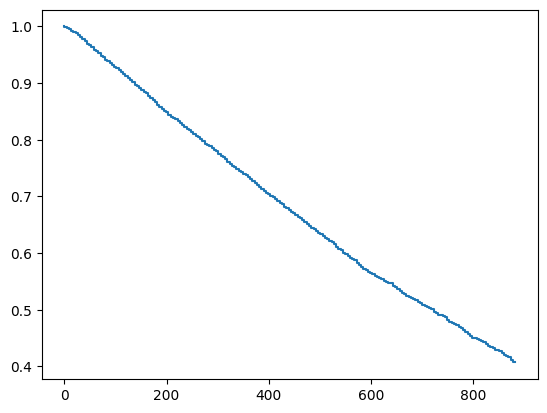

In [80]:
plt.step(times3, predictions3.iloc[0])